In [ ]:
import flopy
import pyemu
import shutil
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Intro

This notebook runs a prior monte carlo using the pest setup generated in the `setup_pstfrom` notebook. We will run the prior parameter ensemble once and stop. We will take a look at some of the results.

### Warning
This notebook can take some time to run. That is the cost of a >5min model run time...imagine if your model takes longer than that (#suffering). For context, this takes about 60min on a MacBook Pro. Expect longer on Windows. We recommend setting this to run over night or when you go out for lunch, before proceeding to the next notebooks. 

In [2]:
# specify the temporary working folder
t_d = Path('priormc')
# get the previously generated PEST dataset
org_t_d = Path('pst_template')
if not Path.exists(org_t_d):
    raise Exception()
if Path.exists(t_d):
    shutil.rmtree(t_d)
shutil.copytree(org_t_d,t_d)

PosixPath('priormc')

# Prior Monte Carlo

Load the pest control file

In [3]:
pst = pyemu.Pst(str(t_d/"pest.pst"))

Lets run the full 1000 realizations. (Why will become evident when we reach the `dsi-ae` notebook...)

In [4]:
pst.pestpp_options["ies_num_reals"] = 100
pst.pestpp_options["save_binary"] = True

Set noptmax=-1 to just run the ensemble once. And lets store results in binary format for speed and disk savings...

In [5]:
pst.control_data.noptmax = -1
# pst.pestpp_options["panther_agent_freeze_on_fail"] = True
pst.write(t_d/"pest.pst",version=2)

noptmax:-1, npar_adj:641, nnz_obs:20189


### Warning: set num_workers according to your reserouces

The model took ~6 min to run... so that would be about 10h for the full 100 runs in serial. Gonna need to run them in parallel to be reasonable. 

With 10 agents we should be looking at about 1.6h instead..a bit more manageable. 

In [6]:
num_workers = 20
m_d = Path("master_priormc")

In [7]:

pyemu.os_utils.start_workers(t_d, # the folder which contains the "template" PEST dataset
                            'pestpp-ies', #the PEST software version we want to run
                            'pest.pst', # the control file to use with PEST
                            num_workers=num_workers, #how many agents to deploy
                            worker_root='.', #where to deploy the agent directories; relative to where python is running
                            master_dir=m_d, #the manager directory
                            cleanup=False
                            )

2026-06-12 22:27:43,160 - MainProcess - INFO - Reserved port 4024 for process 36533




             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team

...processing command line: ' ./pestpp-ies pest.pst /h :4024'
...using panther run manager in master mode using port 4024


version: 5.2.26
binary compiled on Apr  9 2026 at 08:09:49
using control file: "pest.pst"
in directory: "/Users/portega/dev/code/imwa-workshop-2026/tutorial/master_priormc"
on host: "windrunner"
on a(n) apple operating system
with release configuration
started at 06/12/26 22:27:43

processing control file pest.pst


:~-._                                                 _.-~:
: :.~^o._        ________---------________        _.o^~.:.:
 : ::.`?88booo~~~.::::::::...::::::::::::..~~oood88P'.::.:
 :  ::: `?88P .:::....         ........:::::. ?88P' :::. :
  :  :::. `? .::.            . ...........:::. P' .:::. :
   :  :::   ... ..  ...       .. .::::......::.   :::. :
   `  :' .... ..  .:::::.     . ..:::::::....:::.  `: .'
    :..    ____:::::::::.  . . ....

## Load results

In [8]:
pst = pyemu.Pst(str(m_d/"pest.pst"))

In [9]:
sim = flopy.mf6.MFSimulation.load(sim_ws=m_d, load_only=[],verbosity_level=0)
gwf = sim.get_model('gwf')

In [10]:
obs = pst.observation_data
obs

,obsnme,obsval,weight,obgnme,i,j,oname,otype,time,totim,usecol,zone
obsnme,,,,,,,,,,,,
oname:hk_otype:arr_i:0_j:0_zone:1,oname:hk_otype:arr_i:0_j:0_zone:1,5.000000,1.0,hk,0,0,hk,arr,NaN,NaN,NaN,1
oname:hk_otype:arr_i:0_j:10_zone:1,oname:hk_otype:arr_i:0_j:10_zone:1,5.000000,1.0,hk,0,10,hk,arr,NaN,NaN,NaN,1
oname:hk_otype:arr_i:0_j:11_zone:1,oname:hk_otype:arr_i:0_j:11_zone:1,5.000000,1.0,hk,0,11,hk,arr,NaN,NaN,NaN,1
oname:hk_otype:arr_i:0_j:12_zone:1,oname:hk_otype:arr_i:0_j:12_zone:1,5.000000,1.0,hk,0,12,hk,arr,NaN,NaN,NaN,1
oname:hk_otype:arr_i:0_j:13_zone:1,oname:hk_otype:arr_i:0_j:13_zone:1,5.000000,1.0,hk,0,13,hk,arr,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
oname:hdspit_otype:lst_usecol:hds_pit_i:27_j:27_time:18251,oname:hdspit_otype:lst_usecol:hds_pit_i:27_j:27_time:18251,61.830837,1.0,oname:hdspit_otype:lst_usecol:hds_pit_i:27_j:27,27,27,hdspit,lst,18251,NaN,hds,NaN
oname:hdspit_otype:lst_usecol:hds_pit_i:27_j:27_time:54751,oname:hdspit_otype:lst_usecol:hds_pit_i:27_j:27_time:54751,81.316418,1.0,oname:hdspit_otype:lst_usecol:hds_pit_i:27_j:27,27,27,hdspit,lst,54751,NaN,hds,NaN
oname:drn_otype:lst_usecol:drn-gde_time:1,oname:drn_otype:lst_usecol:drn-gde_time:1,-7051.259026,1.0,oname:drn_otype:lst_usecol:drn-gde,NaN,NaN,drn,lst,1,NaN,drn-gde,NaN


## Exploring prior forecast uncertainty

At this point we can check the uncertainty of the predictions before "calibration".

In [11]:
# prior observation/forecast ensemble (one row per realization)
oe = pst.ies.obsen

# the forecasts flagged in the control file
forecasts = [f.strip() for f in pst.pestpp_options["forecasts"].split(",")]
forecasts.sort()
forecasts

pest.obs.


['oname:drn_otype:lst_usecol:drn-gde_time:18251',
 'oname:drn_otype:lst_usecol:drn-gde_time:54751',
 'oname:gde-ph_otype:lst_usecol:ph_min_time:18251',
 'oname:gde-ph_otype:lst_usecol:ph_min_time:54751',
 'oname:hdspit_otype:lst_usecol:hds_pit_i:27_j:27_time:18251']

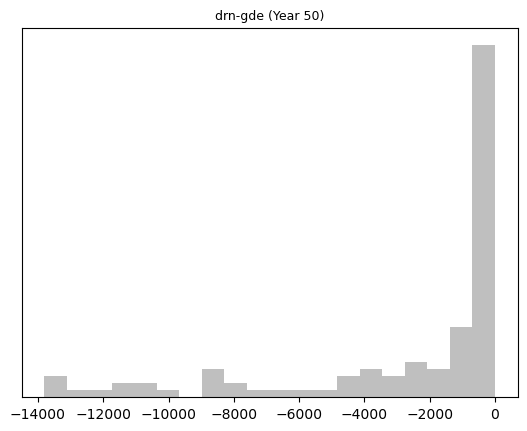

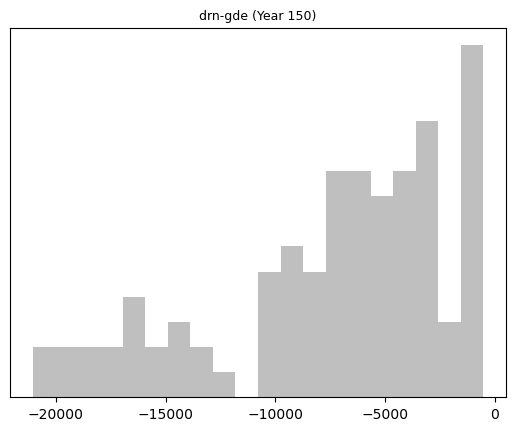

In [12]:
drn_forecasts = [f for f in forecasts if "drn-gde" in f]
# prior distribution of every forecast
for f in drn_forecasts:
    ax = oe.loc[:, f].plot(kind="hist", fc="0.5", alpha=0.5, density=True, bins=20)
    ax.set_title(f"drn-gde (Year {int(int(f.split("time:")[-1])/365)})", fontsize=9)
    ax.set_yticks([])
    ax.set_ylabel("")
    # ax.legend()
    plt.show()

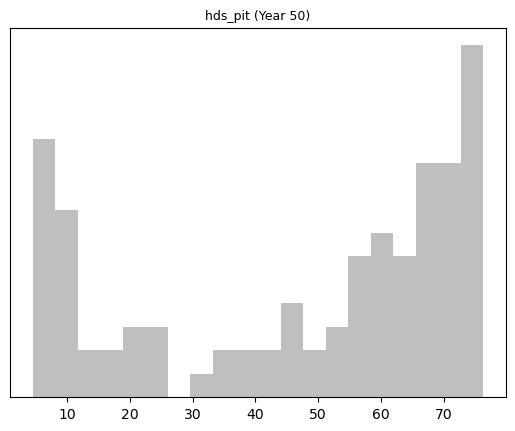

In [13]:
dew_forecasts = [f for f in forecasts if "hds_pit" in f]
# prior distribution of every forecast
for f in dew_forecasts:
    ax = oe.loc[:, f].plot(kind="hist", fc="0.5", alpha=0.5, density=True, bins=20)
    ax.set_title(f"hds_pit (Year {int(int(f.split("time:")[-1])/365)})", fontsize=9)
    ax.set_yticks([])
    ax.set_ylabel("")
    # ax.legend()
    plt.show()

### The management forecast for this exercise

The key forecast for this AMD problem is **pH at the GDE** (`gde-ph ... ph_min`) — the
management criterion is to keep it **above pH 5** at all times. Below we highlight the
GDE-pH forecasts against that threshold and report the prior probability of breaching it.
(The drain flux `drn-gde` is the companion GDE forecast.)

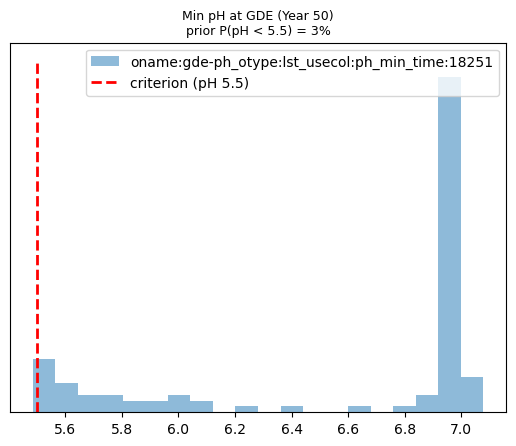

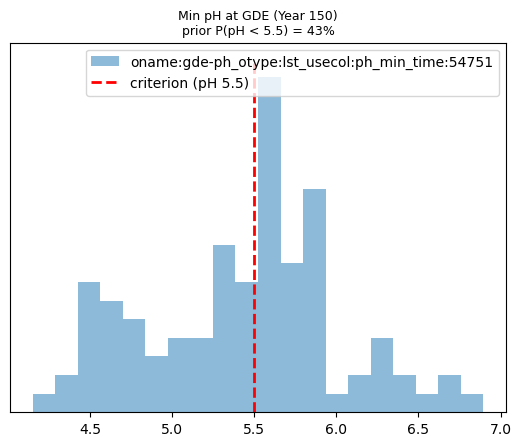

In [14]:
# highlight the management forecast: minimum pH at the GDE vs the criterion
criterion = 5.5
ph_forecasts = [f for f in forecasts if "gde-ph" in f]

for f in ph_forecasts:
    ax = oe.loc[:, f].plot(kind="hist", fc="tab:blue", alpha=0.5, density=True, bins=20)
    yl = ax.get_ylim()
    ax.plot([criterion, criterion], yl, "r--", lw=2, label=f"criterion (pH {criterion:g})")
    p_breach = 100.0 * (oe.loc[:, f] < criterion).mean()
    ax.set_title(f"Min pH at GDE (Year {int(int(f.split("time:")[-1])/365)})\nprior P(pH < {criterion:g}) = {p_breach:.0f}%", fontsize=9)
    ax.set_yticks([])
    ax.set_ylabel("")
    ax.legend()
    plt.show()

## Prior parameter fields

The forecast spread comes from the prior parameter ensemble. Here are the spatial fields
being varied — hydraulic conductivity, porosity, and calcite (the acid-neutralising buffer).
These are the arrays applied for one prior realization in the master directory.

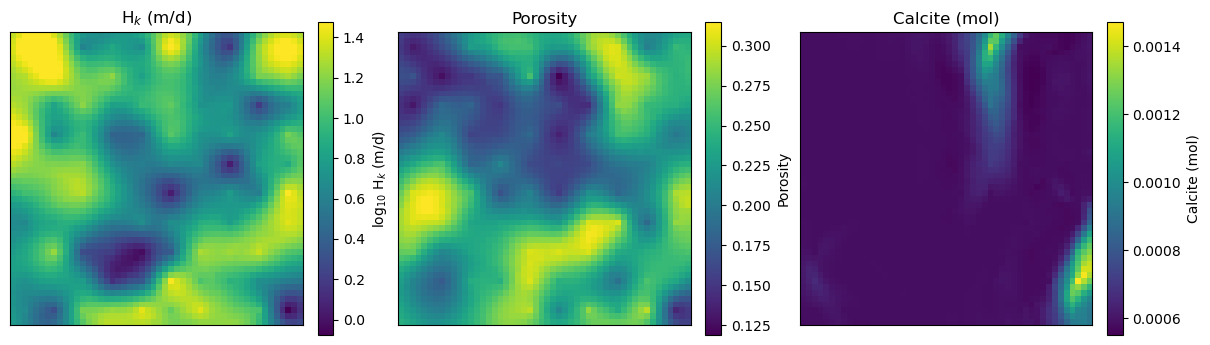

In [15]:
# parameter arrays are PHREEQC/MODFLOW external files in the master dir
nrow = ncol = int(np.sqrt(np.loadtxt(m_d / "gwf.npf_k.txt").size))
fields = [
    ("H$_k$ (m/d)",   "gwf.npf_k.txt",                          True),   # log scale
    ("Porosity",      "H.mst_porosity.txt",                     False),
    ("Calcite (mol)", "equilibrium_phases.Calcite.m0.layer1.txt", False),
]

fig, axs = plt.subplots(1, len(fields), figsize=(4 * len(fields), 4), constrained_layout=True)
for ax, (title, fname, logit) in zip(axs, fields):
    arr = np.loadtxt(m_d / fname).reshape(nrow, ncol)
    plot_arr = np.log10(arr) if logit else arr
    cb = ax.imshow(plot_arr)
    plt.colorbar(cb, ax=ax, shrink=0.8, label=("log$_{10}$ " + title) if logit else title)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

### Prior parameter uncertainty: porosity and calcite

And the prior *distributions* of representative porosity and calcite parameters — this is the
uncertainty in those inputs that propagates to the forecasts above.

pest.0.par.


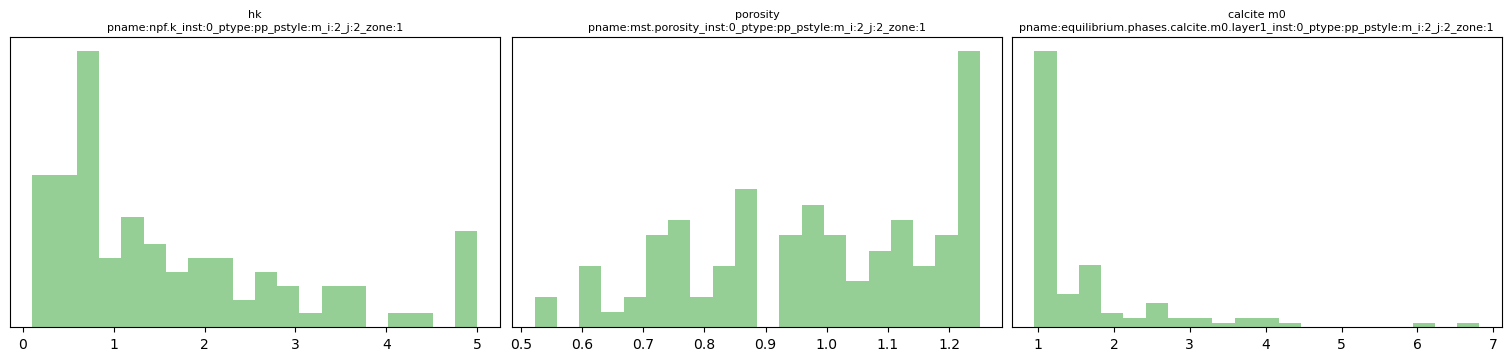

In [16]:
pe = pst.ies.paren0   # prior parameter ensemble
par = pst.parameter_data

# one representative parameter for porosity and for calcite initial moles
examples = {
    "hk": par.loc[par.parnme.str.contains("npf", case=False), "parnme"],
    "porosity": par.loc[par.parnme.str.contains("porosity", case=False), "parnme"],
    "calcite m0": par.loc[par.parnme.str.contains("calcite.m0", case=False), "parnme"],
}
fig, axs = plt.subplots(1, len(examples), figsize=(5 * len(examples), 3.5), constrained_layout=True)
for ax, (label, names) in zip(np.atleast_1d(axs), examples.items()):
    pname = names.iloc[0]
    pe.loc[:, pname].plot(kind="hist", ax=ax, fc="tab:green", alpha=0.5, bins=20, density=True)
    ax.set_title(f"{label}\n{pname}", fontsize=8)
    ax.set_yticks([])
    ax.set_ylabel("")
plt.show()

## Define the truth

In this synthetic experiment we pick one prior realization as the **truth** and pull
"measurements" from it for data assimilation later. We'll bracket the truth's forecasts
with the prior ensemble.

In [17]:
# reload a clean control file (the plotting above didn't change it, but be safe)
pst = pyemu.Pst(str(m_d / "pest.pst"))
oe = pst.ies.obsen
pe = pst.ies.paren0
forecasts = [f.strip() for f in pst.pestpp_options["forecasts"].split(",")]
forecasts.sort()

truth_real = "0"   # the realization we treat as reality

pest.obs.
pest.0.par.


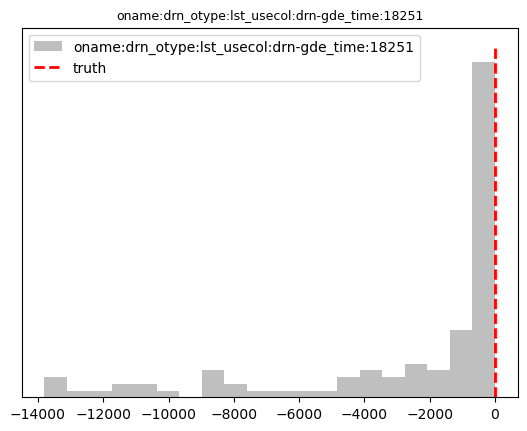

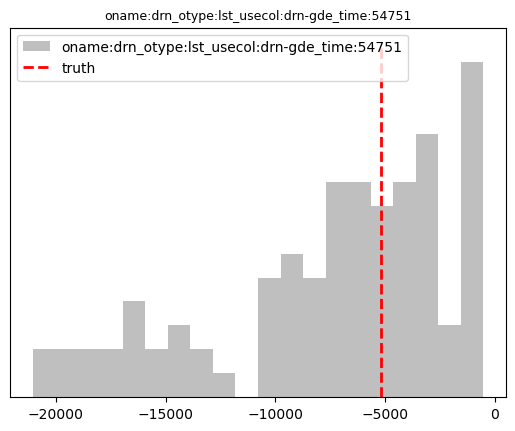

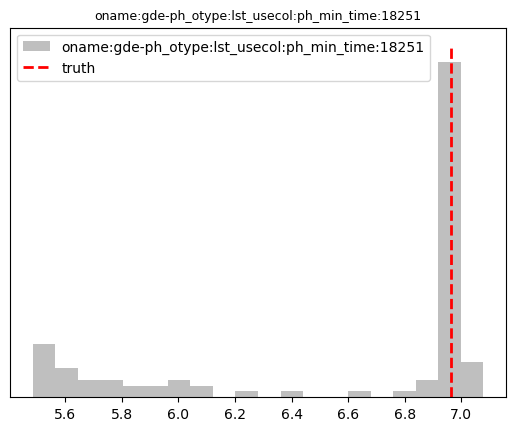

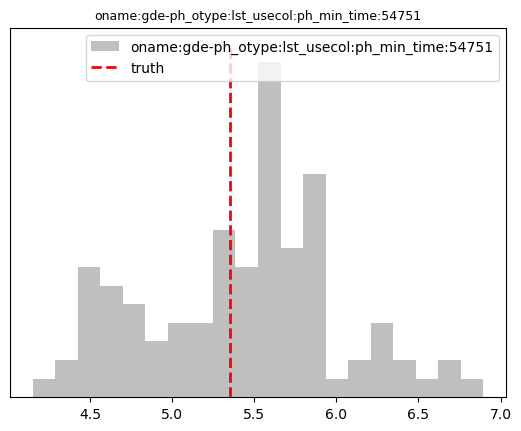

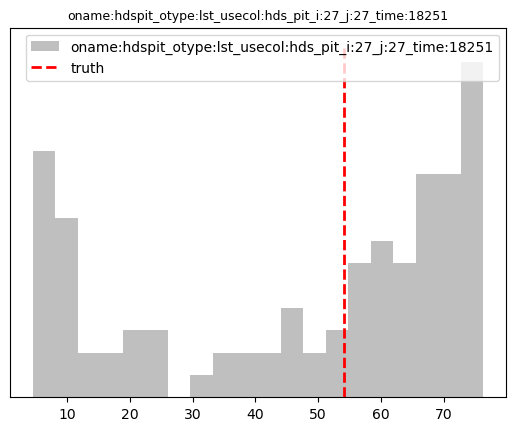

In [18]:
# the prior forecast histograms with the truth value marked
for f in forecasts:
    ax = oe.loc[:, f].plot(kind="hist", fc="0.5", alpha=0.5, density=True, bins=20)
    ylim = ax.get_ylim()
    v = oe.loc[truth_real, f]
    ax.plot([v, v], ylim, "r--", lw=2, label="truth")
    ax.set_title(f, fontsize=9)
    ax.set_yticks([]); ax.set_ylabel(""); ax.legend()
    plt.show()

## Run the truth through the model

Set the parameters to the truth realization's values, run once (`noptmax=0`) to generate
the truth's outputs, then we can visualise the truth fields and harvest its observations.

In [19]:
# grab the truth parameter values, keep the originals to restore afterwards
truth_pvals = pe.loc[truth_real, :].values.flatten()
org_pvals = pst.parameter_data.loc[pe.columns, "parval1"].copy()

pst.parameter_data.loc[pe.columns, "parval1"] = truth_pvals
pst.control_data.noptmax = 0
pst.write(str(m_d / "truth.pst"), version=2)

noptmax:0, npar_adj:641, nnz_obs:20189


In [20]:
# run the truth once (this is a full model run ~ a few minutes)
pyemu.os_utils.run("pestpp-ies truth.pst", cwd=str(m_d))

./pestpp-ies truth.pst


             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team

...processing command line: ' ./pestpp-ies truth.pst'
...using serial run manager


version: 5.2.26
binary compiled on Apr  9 2026 at 08:09:49
using control file: "truth.pst"
in directory: "/Users/portega/dev/code/imwa-workshop-2026/tutorial/master_priormc"
on host: "windrunner"
on a(n) apple operating system
with release configuration
started at 06/12/26 22:29:07

processing control file truth.pst

Note: 'NOPTMAX' == 0, switching to forgiveness mode when checking inputs

noptmax = 0, resetting max_run_fail = 1
parameter warning: 41 parameters are at lower bound
parameter warning: 18 parameters are at upper bound
7 parameter warnings, see rec file 
checking model IO files...done
              starting serial run manager ...


  ---  initializing  ---  

  ---  'noptmax'=0, running control file parameter values and quitting  ---  
...saving control file

### Truth parameter fields

The hydraulic conductivity, porosity, and calcite fields of the realization we're calling truth.

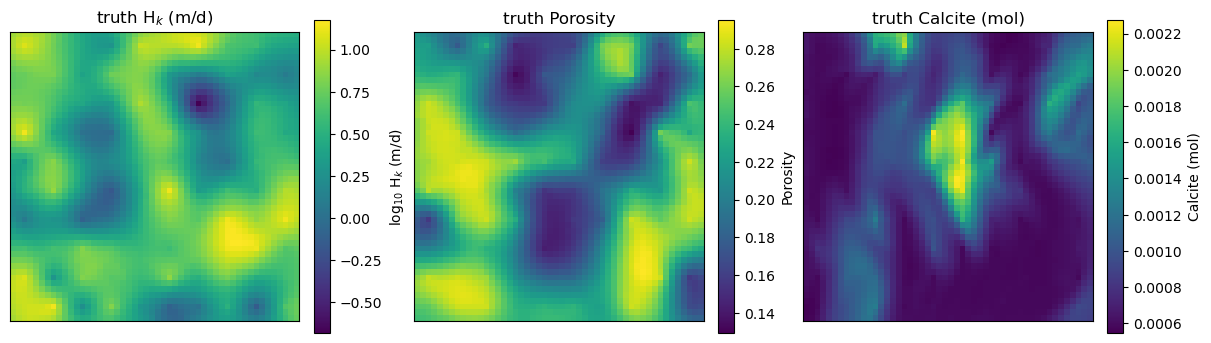

In [21]:
nrow = ncol = int(np.sqrt(np.loadtxt(m_d / "gwf.npf_k.txt").size))
fields = [
    ("H$_k$ (m/d)",   "gwf.npf_k.txt",                            True),
    ("Porosity",      "H.mst_porosity.txt",                       False),
    ("Calcite (mol)", "equilibrium_phases.Calcite.m0.layer1.txt", False),
]
fig, axs = plt.subplots(1, len(fields), figsize=(4 * len(fields), 4), constrained_layout=True)
for ax, (title, fname, logit) in zip(axs, fields):
    arr = np.loadtxt(m_d / fname).reshape(nrow, ncol)
    plot_arr = np.log10(arr) if logit else arr
    cb = ax.imshow(plot_arr)
    plt.colorbar(cb, ax=ax, shrink=0.8, label=("log$_{10}$ " + title) if logit else title)
    ax.set_title("truth " + title)
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

In [22]:
# load the truth results as the 'observed' values
pst.set_res(str(m_d / "truth.base.rei"))

## Initial weighting

Simple weights so a few observations show up in the objective function. These are **not**
the noise weights (next tutorial) -- just for visibility. We weight the heads at the MAR /
dewatering well cells, the GDE drain flux, and the **GDE pH** (the management quantity) -- all
at the first reporting time. The pH at later times (18251, 54751) stays weight 0: those are the forecasts.

In [26]:
par = pst.parameter_data
wpar = par.loc[(par.parnme.str.contains("mar")) | (par.parnme.str.contains("dewater")), :].copy()
wpar["i"] = wpar.idx1.astype(int)
wpar["j"] = wpar.idx2.astype(int)
ijs = set([(i, j) for i, j in zip(wpar.i, wpar.j)])

obs = pst.observation_data
obs["weight"] = 0.0
# use the truth as the observed values
obs.loc[:, "obsval"] = pst.res.loc[pst.obs_names, "modelled"].values

# head observations at the well cells -> weight = 10 (sigma = 0.1 m)
hobs = obs.loc[obs.obsnme.str.contains("hdslay1_t1"), :].copy()
assert hobs.shape[0] > 0
hobs["ij"] = hobs.apply(lambda x: (int(x.i), int(x.j)), axis=1)
nzhobs = hobs.loc[hobs.ij.isin(ijs)]
assert len(nzhobs) == len(ijs)
obs.loc[nzhobs.obsnme, "weight"] = 10.0

# GDE drain flux at the first reporting time -> weight = 1 / (20% of |value|)
drnobs = obs.loc[(obs.usecol == "drn-gde") & (obs.time == "1"), :]
assert len(drnobs) == 1
obs.loc[drnobs.obsnme, "weight"] = 1.0 / (np.abs(obs.loc[drnobs.obsnme, "obsval"]) * 0.2)

# GDE pH measurement at the first reporting time -> weight = 10 (sigma = 0.1 pH unit)
# (the management quantity; the pH at times 18251 & 54751 stay weight 0 -- those are forecasts)
phobs = obs.loc[(obs.usecol == "ph") & (obs.time.astype(str) == "1"), :]
assert len(phobs) == 1
obs.loc[phobs.obsnme, "weight"] = 10.0

assert pst.nnz_obs == len(ijs) + 2
print(f"non-zero-weight observations: {pst.nnz_obs}  ({len(ijs)} heads + 1 drain + 1 GDE pH)")

non-zero-weight observations: 31  (29 heads + 1 drain + 1 GDE pH)


## Restore the prior and remove the truth

Write the weighted control file back to the template, restore the original (prior-mean)
parameter values, and drop the truth realization from the prior ensemble so we don't cheat.

In [27]:
# restore prior-mean parameter values and write the weighted control file to the template
pst.parameter_data["parval1"] = org_pvals
pst.control_data.noptmax = -1
pst.write(str(t_d / "pest.pst"), version=2)

noptmax:-1, npar_adj:641, nnz_obs:31


In [28]:
# remove the truth (and any 'base') realization from the prior parameter ensemble
pe.drop(truth_real, inplace=True)
if "base" in pe.index:
    pe.drop("base", inplace=True)
pyemu.ParameterEnsemble(df=pe, pst=pst).to_binary(str(t_d / "prior_pe.jcb"))
print(f"prior ensemble now has {pe.shape[0]} realizations (truth removed)")

prior ensemble now has 98 realizations (truth removed)
